# Predicting Student Dropout & Academic Success
### Machine Learning Project

**Goal:** Predict whether a student will **Dropout**, remain **Enrolled**, or **Graduate**, using only information available at enrollment time plus 1st/2nd semester academic performance.

**In this notebook:**
- ** Data cleaning, EDA, feature engineering**

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

## Load, Clean & Explore the Data

In [2]:
df_student = pd.read_csv("data.csv", sep = ';')

In [3]:
df_student.columns = [c.strip() for c in df_student.columns]

print(df_student.shape)
df_student.head()

(4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
print("Columns:", df_student.columns.tolist())
df_student.info()

Columns: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']
<cla

In [5]:
# Integrity checks
print("Missing values:", df_student.isna().sum().sum())
print("Duplicate rows:", df_student.duplicated().sum())
print(df_student.dtypes.value_counts())
df_student.describe().T

Missing values: 0
Duplicate rows: 0
int64      29
float64     7
object      1
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [6]:
print("Missing values per column:")
print(df_student.isna().sum().sort_values(ascending=False))

print("Total duplicates:", df_student.duplicated().sum())

Missing values per column:
Marital status                                    0
Age at enrollment                                 0
Curricular units 1st sem (credited)               0
Curricular units 1st sem (enrolled)               0
Curricular units 1st sem (evaluations)            0
Curricular units 1st sem (approved)               0
Curricular units 1st sem (grade)                  0
Curricular units 1st sem (without evaluations)    0
Curricular units 2nd sem (credited)               0
Curricular units 2nd sem (enrolled)               0
Curricular units 2nd sem (evaluations)            0
Curricular units 2nd sem (approved)               0
Curricular units 2nd sem (grade)                  0
Curricular units 2nd sem (without evaluations)    0
Unemployment rate                                 0
Inflation rate                                    0
GDP                                               0
International                                     0
Scholarship holder                   

In [7]:
#Target distribution
target_col = "Target"

print(df_student[target_col].value_counts())
print(df_student[target_col].value_counts(normalize=True).round(3))

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


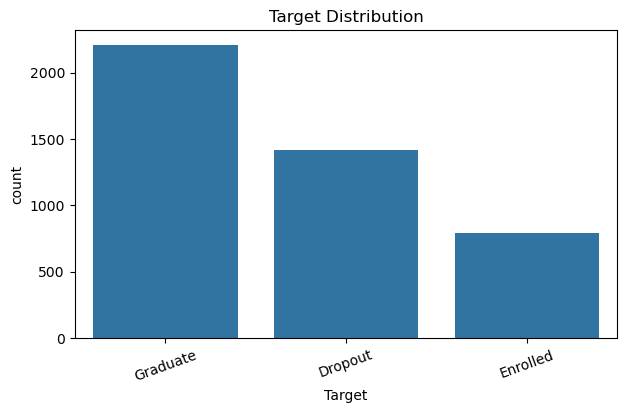

In [8]:
#Visualize Target distribution
plt.figure(figsize=(7,4))
sns.countplot(data=df_student, x=target_col, order=df_student[target_col].value_counts().index)
plt.title("Target Distribution")
plt.xticks(rotation=20)
plt.show()


In [9]:
# Categorical summary
cat_cols = df_student.select_dtypes(include=["object", "category"]).columns
for col in cat_cols:
    print(f"\n{col}")
    print(df_student[col].value_counts().head())



Target
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [10]:
target_counts = df_student['Target'].value_counts()
print(target_counts)
print(df_student['Target'].value_counts(normalize=True).round(3))


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64


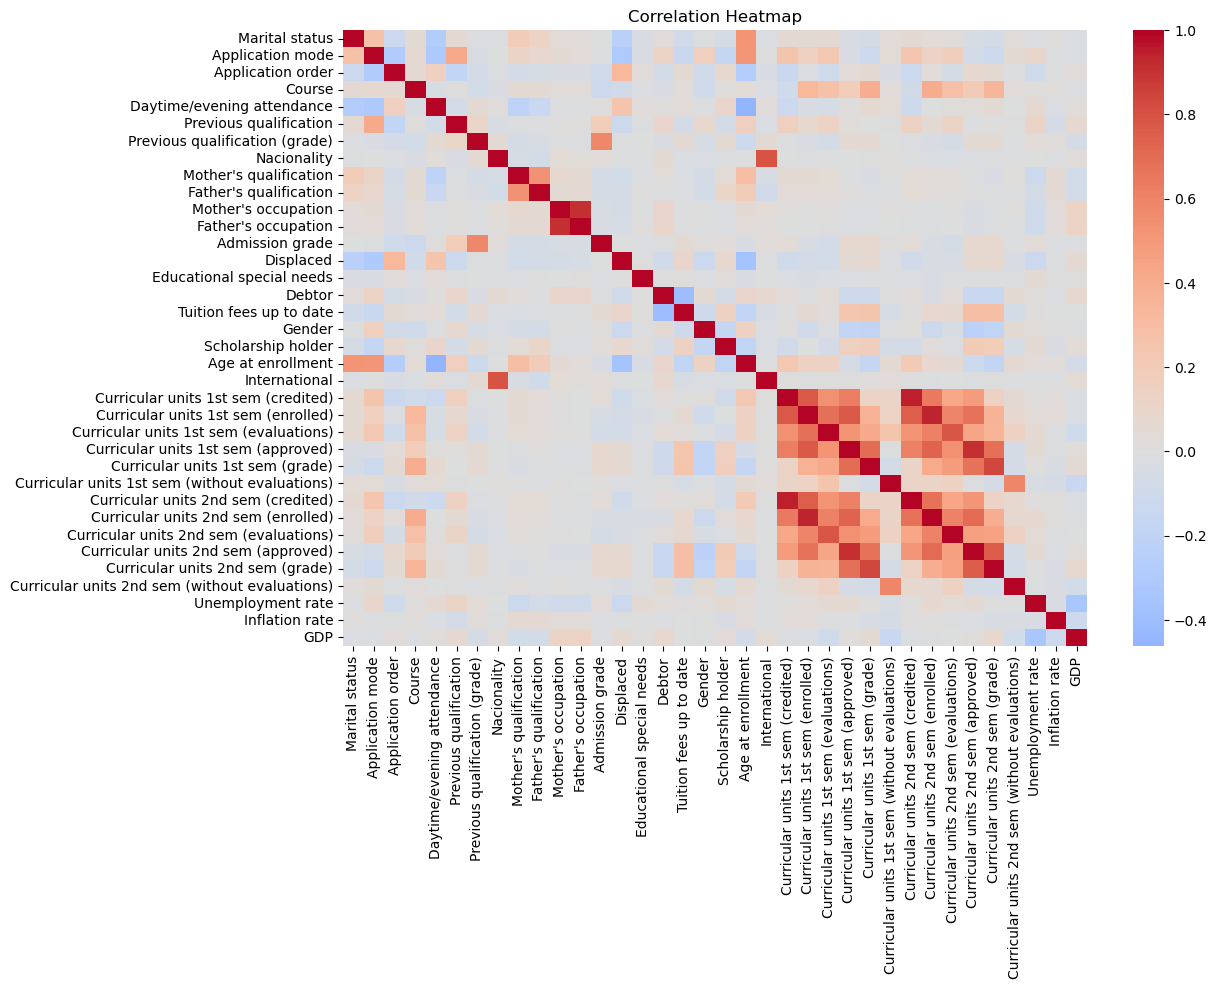

In [11]:
# Correlation heatmap for numeric columns
plt.figure(figsize=(12,8))
sns.heatmap(df_student.select_dtypes(include=np.number).corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
correlation_matrix_df = df_student.select_dtypes(include=np.number).corr()

In [13]:
correlation_matrix_df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,...,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,0.042858,0.070952,-0.000571,0.087654,0.002620,0.065789,0.038695,0.044945,0.048731,0.046592,...,0.059156,0.171429,0.209215,0.182151,0.190762,0.148352,0.049603,0.022659,0.021359,0.015827
std,0.209099,0.239285,0.204390,0.212113,0.213992,0.191558,0.197911,0.212402,0.204148,0.197312,...,0.200268,0.301861,0.317344,0.274776,0.324874,0.292670,0.196910,0.186222,0.171036,0.188070
min,-0.274939,-0.304092,-0.286357,-0.125058,-0.462280,-0.184315,-0.111377,-0.085282,-0.204767,-0.139894,...,-0.144673,-0.125815,-0.124227,-0.061355,-0.224266,-0.199133,-0.080292,-0.335178,-0.112295,-0.335178
25%,-0.029014,-0.032840,-0.090208,-0.028221,-0.043836,-0.011143,-0.037885,-0.018438,-0.041364,-0.038998,...,-0.018418,-0.008215,-0.009089,-0.006353,-0.019551,-0.023337,-0.022859,-0.022474,-0.024174,-0.033408
50%,0.014593,0.046905,-0.029408,0.029849,0.007314,0.015542,-0.011208,-0.007363,0.010979,0.002985,...,0.003035,0.041446,0.047602,0.035004,0.041413,0.051866,-0.005830,0.014141,-0.008018,-0.006223
75%,0.053588,0.161172,0.040564,0.094164,0.040507,0.106044,0.050846,0.011491,0.052662,0.051771,...,0.048738,0.215282,0.402696,0.428628,0.447583,0.309542,0.055748,0.046800,0.017960,0.037835
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
df_student['Marital status'].unique()

array([1, 2, 4, 3, 5, 6])

In [15]:
crosstab_df = pd.crosstab(df_student['Marital status'], df_student['Target'])
crosstab_df

Target,Dropout,Enrolled,Graduate
Marital status,,,
1,1184,720,2015
2,179,52,148
3,1,2,1
4,42,16,33
5,11,3,11
6,4,1,1


In [16]:
from scipy.stats import chi2_contingency

In [17]:
chi2_contingency(crosstab_df)

Chi2ContingencyResult(statistic=np.float64(63.43854947026341), pvalue=np.float64(8.054279703889306e-10), dof=10, expected_freq=array([[1.25879272e+03, 7.03364828e+02, 1.95684245e+03],
       [1.21735759e+02, 6.80212477e+01, 1.89242993e+02],
       [1.28481013e+00, 7.17902351e-01, 1.99728752e+00],
       [2.92294304e+01, 1.63322785e+01, 4.54382911e+01],
       [8.03006329e+00, 4.48688969e+00, 1.24830470e+01],
       [1.92721519e+00, 1.07685353e+00, 2.99593128e+00]]))

In [18]:
df_student.groupby('Target')['Previous qualification (grade)'].mean()

Target
Dropout     131.114075
Enrolled    131.208438
Graduate    134.082707
Name: Previous qualification (grade), dtype: float64

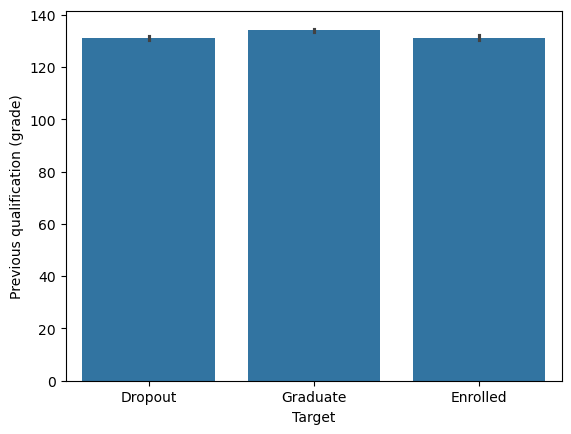

In [19]:
sns.barplot(data=df_student, x='Target', y='Previous qualification (grade)');

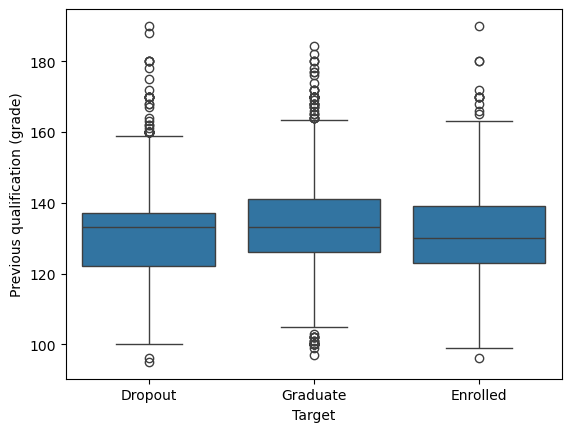

In [20]:
sns.boxplot(data=df_student, x='Target', y='Previous qualification (grade)');

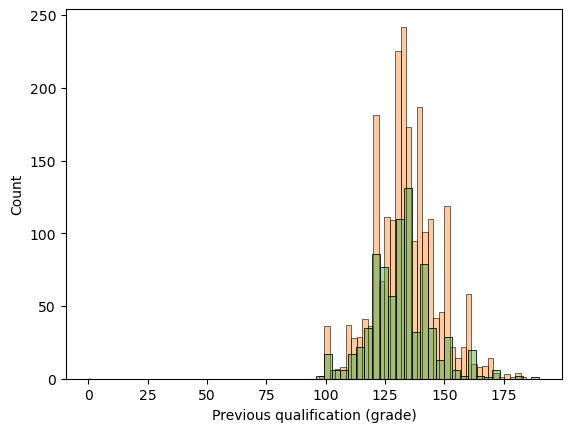

In [21]:
fig, axes = plt.subplots()
sns.histplot(data=df_student[df_student['Target'] == "Droupout"], x='Previous qualification (grade)', alpha=0.4, ax=axes);
sns.histplot(data=df_student[df_student['Target'] == "Graduate"], x='Previous qualification (grade)', alpha=0.4, ax=axes);
sns.histplot(data=df_student[df_student['Target'] == "Enrolled"], x='Previous qualification (grade)', alpha=0.4, ax=axes);
plt.show()

In [22]:
# Target column = Categorical
# Categorical vs categorical -> Chi2
# Numerical vs Categorical -> groupby

In [23]:
df_student.columns=(df_student.columns.str.strip().str.replace(r"\s+", "_", regex=True))

In [24]:
df_student.columns

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime/evening_attendance', 'Previous_qualification',
       'Previous_qualification_(grade)', 'Nacionality',
       'Mother's_qualification', 'Father's_qualification',
       'Mother's_occupation', 'Father's_occupation', 'Admission_grade',
       'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_(credited)',
       'Curricular_units_1st_sem_(enrolled)',
       'Curricular_units_1st_sem_(evaluations)',
       'Curricular_units_1st_sem_(approved)',
       'Curricular_units_1st_sem_(grade)',
       'Curricular_units_1st_sem_(without_evaluations)',
       'Curricular_units_2nd_sem_(credited)',
       'Curricular_units_2nd_sem_(enrolled)',
       'Curricular_units_2nd_sem_(evaluations)',
       'Curricular_units_2nd_sem_(approved)',
       'Curricular_units_2nd_s

In [25]:
numerical_features = [
    "Admission_grade",
    "Age_at_enrollment",
    'Curricular_units_1st_sem_(credited)',
    'Curricular_units_1st_sem_(enrolled)',
    'Curricular_units_1st_sem_(evaluations)',
    'Curricular_units_1st_sem_(approved)',
]

categorical_features = [
    "Displaced",
    "Educational_special_needs",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
    "International"
]

In [26]:
# chi-square and crosstab for categorical

from scipy.stats import chi2_contingency

for col in categorical_features:
    print(f"\n{ '-' * 60}")
    print()
    print(col.upper())

    # Crosstab
    table = pd.crosstab(df_student[col],df_student["Target"])

    # Crosstab - percentages
    table_percent = pd.crosstab(
    df_student[col],
    df_student["Target"],
    normalize="index"
    ) * 100
    

    print("\nCrosstab:")
    display(table)
    # display(table_percent)

    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(table)

    print(f"\n Chi-square p-value: {p_value:.4f}")



------------------------------------------------------------

DISPLACED

Crosstab:


Target,Dropout,Enrolled,Graduate
Displaced,,,
0,752,361,885
1,669,433,1324



 Chi-square p-value: 0.0000

------------------------------------------------------------

EDUCATIONAL_SPECIAL_NEEDS

Crosstab:


Target,Dropout,Enrolled,Graduate
Educational_special_needs,,,
0,1404,783,2186
1,17,11,23



 Chi-square p-value: 0.7254

------------------------------------------------------------

DEBTOR

Crosstab:


...


 Chi-square p-value: 0.0000

------------------------------------------------------------

SCHOLARSHIP_HOLDER

Crosstab:


Target,Dropout,Enrolled,Graduate
Scholarship_holder,,,
0,1287,664,1374
1,134,130,835



 Chi-square p-value: 0.0000

------------------------------------------------------------

INTERNATIONAL

Crosstab:


Target,Dropout,Enrolled,Graduate
International,,,
0,1389,770,2155
1,32,24,54



 Chi-square p-value: 0.5273



------------------------------------------------------------

ADMISSION_GRADE



,Admission_grade
Target,
Dropout,124.96
Enrolled,125.53
Graduate,128.79


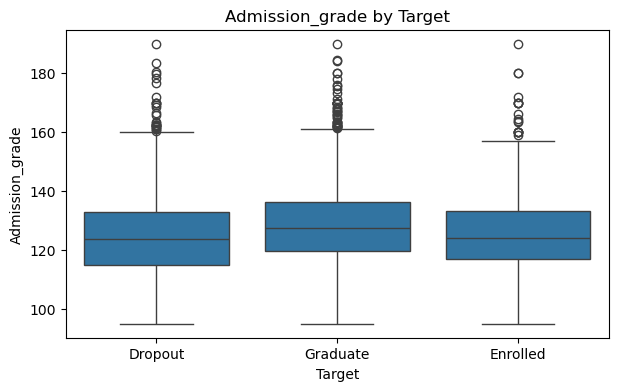


------------------------------------------------------------

AGE_AT_ENROLLMENT



,Age_at_enrollment
Target,
Dropout,26.07
Enrolled,22.37
Graduate,21.78


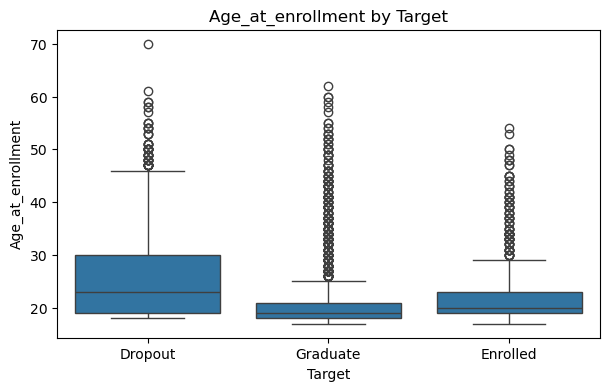


------------------------------------------------------------

CURRICULAR_UNITS_1ST_SEM_(CREDITED)



,Curricular_units_1st_sem_(credited)
Target,
Dropout,0.61
Enrolled,0.51
Graduate,0.85


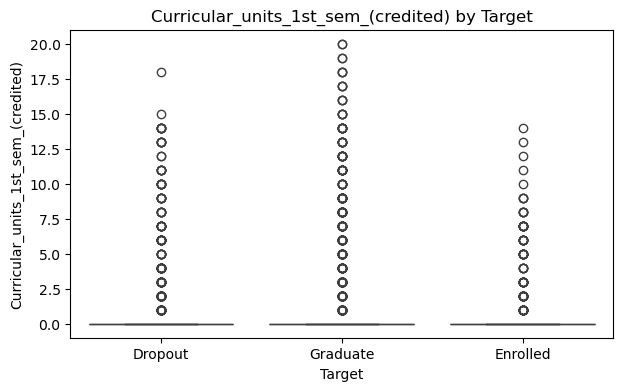


------------------------------------------------------------

CURRICULAR_UNITS_1ST_SEM_(ENROLLED)



,Curricular_units_1st_sem_(enrolled)
Target,
Dropout,5.82
Enrolled,5.96
Graduate,6.67


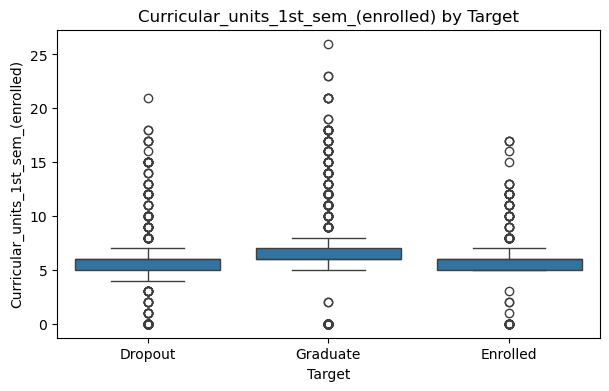


------------------------------------------------------------

CURRICULAR_UNITS_1ST_SEM_(EVALUATIONS)



,Curricular_units_1st_sem_(evaluations)
Target,
Dropout,7.75
Enrolled,9.34
Graduate,8.28


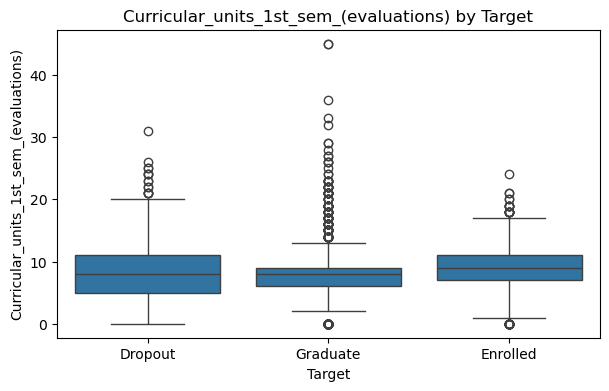


------------------------------------------------------------

CURRICULAR_UNITS_1ST_SEM_(APPROVED)



,Curricular_units_1st_sem_(approved)
Target,
Dropout,2.55
Enrolled,4.32
Graduate,6.23


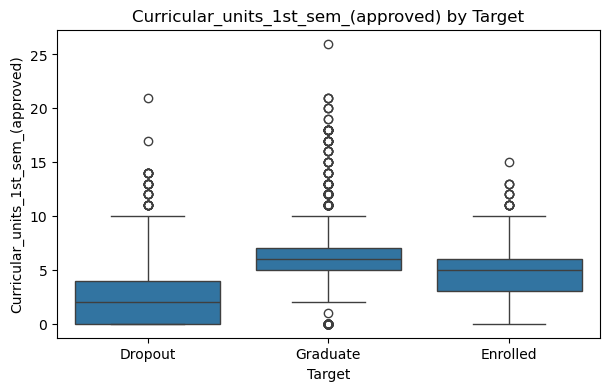

In [27]:
# boxplot for numerical

for col in numerical_features:
    print(f"\n{'-'* 60}")
    print()
    print(col.upper())
    print()

    # Mean by Target
    display(df_student.groupby('Target')[[col]].mean().round(2))

    # Boxplot
    plt.figure(figsize=(7, 4))
    sns.boxplot(data = df_student, x='Target',y=col)
    plt.title(f"{col} by Target")
    plt.show()


In [28]:
from scipy.stats import chi2_contingency

results_categorical = []

for col in categorical_features:
    table = pd.crosstab(df_student[col], df_student["Target"])
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    results_categorical.append({
        "Feature": col,
        "Type": "Categorical",
        "Test": "Chi-square",
        "p-value": p_value
    })

categorical_results = pd.DataFrame(results_categorical)
categorical_results

,Feature,Type,Test,p-value
0,Displaced,Categorical,Chi-square,2.876311e-13
1,Educational_special_needs,Categorical,Chi-square,7.254050e-01
2,Debtor,Categorical,Chi-square,4.858552e-57
3,Tuition_fees_up_to_date,Categorical,Chi-square,1.471628e-179
4,Gender,Categorical,Chi-square,2.222480e-51
5,Scholarship_holder,Categorical,Chi-square,9.593930e-90
6,International,Categorical,Chi-square,5.273144e-01


In [29]:
from scipy.stats import kruskal

results_numerical = []

for col in numerical_features:
    groups = [
        df_student.loc[df_student["Target"] == target, col]
        for target in df_student["Target"].unique()
    ]
    
    statistic, p_value = kruskal(*groups)
    means = df_student.groupby("Target")[col].mean() 
    results_numerical.append({
        "Feature": col,
        "Type": "Numerical",
        "p-value": p_value,
        "Dropout_mean": means.get("Dropout"),
        "Enrolled_mean": means.get("Enrolled"),
        "Graduate_mean": means.get("Graduate")
    })

numerical_results = pd.DataFrame(results_numerical)
numerical_results

,Feature,Type,p-value,Dropout_mean,Enrolled_mean,Graduate_mean
0,Admission_grade,Numerical,1.251093e-16,124.961365,125.534257,128.794432
1,Age_at_enrollment,Numerical,3.520194e-82,26.068966,22.369018,21.783612
2,Curricular_units_1st_sem_(credited),Numerical,2.999970e-01,0.609430,0.507557,0.847442
3,Curricular_units_1st_sem_(enrolled),Numerical,2.803949e-54,5.821253,5.964736,6.669534
4,Curricular_units_1st_sem_(evaluations),Numerical,4.244301e-29,7.751583,9.341310,8.276596
5,Curricular_units_1st_sem_(approved),Numerical,0.000000e+00,2.551724,4.318640,6.232232


#### Suggestion Feature Selection

To make a first feature selection, we analysed the relationship between each feature and the `Target` variable.

- Categorical features: we used a Chi-square test. Features with a low p-value were considered to have a statistically significant relationship with `Target`.
- Numerical features: we compared the mean values across the three Target categories (`Dropout`, `Enrolled`, and `Graduate`) and used a statistical test to assess whether the differences were significant.

Based on this preliminary analysis, our initial proposal is:

Keep
- `Displaced`
- `Debtor`
- `Tuition_fees_up_to_date`
- `Gender`
- `Scholarship_holder`
- `Admission_grade`
- `Age_at_enrollment`
- `Curricular_units_1st_sem_(enrolled)`
- `Curricular_units_1st_sem_(evaluations)`
- `Curricular_units_1st_sem_(approved)`

Consider removing
- `Educational_special_needs`
- `International`
- `Curricular_units_1st_sem_(credited)`

If selecting only 5 features, my proposal would be:
1. `Age_at_enrollment`
2. `Admission_grade`
3. `Curricular_units_1st_sem_(approved)`
4. `Curricular_units_1st_sem_(enrolled)`
5. `Curricular_units_1st_sem_(evaluations)`


We selected the variables based on their statistical relationship with the target, using the Chi-square test for categorical variables and a statistical test plus group means for numerical variables. So we selected the most promising variables as candidates for the model.